## 1. Import Required Libraries

In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
from scipy.ndimage import gaussian_filter
import pandas as pd
import colormaps as cmaps
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

# Set matplotlib defaults for better-looking plots
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Configuration

Set the source, hemisphere, and overlap category to visualize.

In [2]:
# Configuration
source = "era5"  # Options: 'era5, 'scream', 'nicam_gl11', 'icon_d3hp003', 'um_glm_n2560_RAL3p3', 'casesm2_10km_nocumulus'
hemisphere = "nh"  # Options: 'nh' (Northern Hemisphere), 'sh' (Southern Hemisphere)
overlap_type = "3way"  # Options: 'isolated', 'mcs_only', 'ar_only', '3way', 'all'

source_map = {
    "era5": "ERA5",
    "scream": "SCREAM",
    "nicam_gl11": "NICAM",
    "icon_d3hp003": "ICON",
    "um_glm_n2560_RAL3p3": "UM",
    "casesm2_10km_nocumulus": "CASESM2",
}

# Data paths
data_dir = f"/pscratch/sd/w/wcmca1/hackathon/etc_data/stats/{source}/"
composite_file = f"{data_dir}etc_2d_composite_{hemisphere}_{overlap_type}.nc"

# Figure output directory
# figdir = f"/pscratch/sd/w/wcmca1/hackathon/figures_etc_composites/{source}/"
figdir = f"/global/cfs/cdirs/m1867/zfeng/hk25/figures_etc_composites/{source}/"
os.makedirs(figdir, exist_ok=True)

print(f"Source: {source}")
print(f"Hemisphere: {hemisphere.upper()}")
print(f"Overlap type: {overlap_type}")
print(f"Composite file: {composite_file}")

Source: era5
Hemisphere: NH
Overlap type: 3way
Composite file: /pscratch/sd/w/wcmca1/hackathon/etc_data/stats/era5/etc_2d_composite_nh_3way.nc


## 3. Load Composite Data

In [3]:
# Load the composite NetCDF file
print(f"Loading composite data...")
ds = xr.open_dataset(composite_file)

print(f"\nDataset loaded successfully!")
print(f"Grid dimensions: {len(ds.y)} × {len(ds.x)}")

# Display dataset information
print("\nDataset Dimensions:")
print(ds.dims)

print("\nData Variables:")
for var in ds.data_vars:
    print(f"  {var}: {ds[var].dims} - {ds[var].shape}")

print("\nDataset Attributes:")
for key, val in ds.attrs.items():
    print(f"  {key}: {val}")

Loading composite data...



Dataset loaded successfully!
Grid dimensions: 161 × 161

Dataset Dimensions:
FrozenMappingWarningOnValuesAccess({'y': 161, 'x': 161})

Data Variables:
  ar_etc_overlap_mask: ('y', 'x') - (161, 161)
  cof_lat: () - ()
  cof_lon: () - ()
  d2m: ('y', 'x') - (161, 161)
  etc_ar_overlap_mask: ('y', 'x') - (161, 161)
  etc_mcs_overlap_mask: ('y', 'x') - (161, 161)
  hur_500hPa: ('y', 'x') - (161, 161)
  hur_850hPa: ('y', 'x') - (161, 161)
  hus_500hPa: ('y', 'x') - (161, 161)
  hus_850hPa: ('y', 'x') - (161, 161)
  lat_id: () - ()
  lon_id: () - ()
  mcs_etc_overlap_mask: ('y', 'x') - (161, 161)
  omega_500hPa: ('y', 'x') - (161, 161)
  omega_850hPa: ('y', 'x') - (161, 161)
  overlap_flag: () - ()
  pr: ('y', 'x') - (161, 161)
  prw: ('y', 'x') - (161, 161)
  ps: ('y', 'x') - (161, 161)
  psl: ('y', 'x') - (161, 161)
  sstk: ('y', 'x') - (161, 161)
  storm_id: () - ()
  storm_lat: () - ()
  storm_lon: () - ()
  tas: ('y', 'x') - (161, 161)
  u10: ('y', 'x') - (161, 161)
  ua_500hPa: ('y', 

## 4. Create Plotting Function

This function creates a composite visualization with:
- **Shaded variables**: Primary field (e.g., specific humidity) and optional overlay (e.g., precipitation)
- **Contour lines**: Geopotential height
- **Wind vectors**: 850 hPa winds
- **Contour lines2**: optional overlay2 (e.g., MCS frequency)
- **Contour lines3**: optional overlay3 (e.g., AR frequency)

In [4]:
def plot_etc_composite(ds, 
                       shade_var='hus_850hPa', shade_levels=None, shade_cmap='GnBu', 
                       shade_scale=1.0, shade_alpha=1.0, shade_label=None, cbar_ticks=None,
                       shade_var2=None, shade_levels2=None, shade_cmap2='YlGnBu', 
                       shade_scale2=1.0, shade_alpha2=0.9, shade_label2=None, cbar_ticks2=None,
                       shade_levels2_thresh=None, shade_smooth2=0,
                       contour_var='zg_500hPa', contour_levels=None, contour_smooth=2, contour_lw=3.0,
                       contour_var2=None, contour_levels2=None, contour_cmap2=None, contour_color2=None,
                       contour_smooth2=0, contour_lw2=2.0, contour_var2_legend=None,
                       contour_var3=None, contour_levels3=None, contour_cmap3=None, contour_color3=None,
                       contour_smooth3=0, contour_lw3=2.0, contour_var3_legend=None,
                       u_var='ua_850hPa', v_var='va_850hPa', vector_skip=6,
                       quiverkey_length=10, quiverkey_unit=' m/s', quiver_scale=300,
                       circle_radius=None,
                       xlim=None, ylim=None,
                       xlabel='Longitude offset (°)', ylabel='Latitude offset (°)',
                       title=None,
                       figsize=(12, 10), dpi=200, figname=None,
                       main_width_ratios=None, main_wspace=None,
                       cbar_width_ratios=None, cbar_wspace=None):
    """
    Plot composite ETC data with multiple overlays.
    
    [Full docstring same as original - parameters and descriptions]
    """
    
    # Get coordinates and convert to degrees
    lat_res = ds.attrs.get('lat_res', 0.25)
    lon_res = ds.attrs.get('lon_res', 0.25)
    
    x = ds.x.values * lon_res
    y = ds.y.values * lat_res
    X, Y = np.meshgrid(x, y)
    
    # Create figure with GridSpec for better colorbar control
    fig = plt.figure(figsize=figsize, dpi=dpi)

    contour_fontsize = 10
    
    # Determine number of colorbars needed
    has_shade_var2 = shade_var2 is not None and shade_var2 in ds
    
    if has_shade_var2:
        # Set defaults for 2 colorbars case
        if main_width_ratios is None:
            main_width_ratios = [1, 0.2]
        if main_wspace is None:
            main_wspace = 0.03
        if cbar_width_ratios is None:
            cbar_width_ratios = [0.005, 0.005]
        if cbar_wspace is None:
            cbar_wspace = 4
            
        # Create main GridSpec: [plot | colorbars]
        gs_main = gridspec.GridSpec(1, 2, figure=fig, 
                                   width_ratios=main_width_ratios,
                                   wspace=main_wspace)
        
        ax = fig.add_subplot(gs_main[0])
        
        # Create nested GridSpec for the two colorbars
        gs_cbar = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[1],
                                                   width_ratios=cbar_width_ratios,
                                                   wspace=cbar_wspace)
        cax1 = fig.add_subplot(gs_cbar[0])
        cax2 = fig.add_subplot(gs_cbar[1])
    else:
        # Set defaults for 1 colorbar case
        if main_width_ratios is None:
            main_width_ratios = [1, 0.04]
        if main_wspace is None:
            main_wspace = 0.02
            
        # Create GridSpec: [main plot | cbar1]
        gs_main = gridspec.GridSpec(1, 2, figure=fig,
                                   width_ratios=main_width_ratios,
                                   wspace=main_wspace)
        ax = fig.add_subplot(gs_main[0])
        cax1 = fig.add_subplot(gs_main[1])
        cax2 = None
    
    # ===== 1. PRIMARY SHADED VARIABLE (z_order=0) =====
    if shade_var in ds:
        shade_data = ds[shade_var].values * shade_scale
        
        if shade_levels is None:
            vmin, vmax = np.nanpercentile(shade_data, [2, 98])
            shade_levels = np.linspace(vmin, vmax, 20)
        
        cf = ax.contourf(X, Y, shade_data, levels=shade_levels,
                        cmap=shade_cmap, extend='both', alpha=shade_alpha, 
                        antialiased=True, zorder=0)
        cbar = plt.colorbar(cf, cax=cax1, orientation='vertical')
        
        if shade_label is not None:
            cbar_label = shade_label
        else:
            cbar_label = f'{shade_var}'
            if shade_scale != 1.0:
                cbar_label += f' (×{shade_scale})'
        cbar.set_label(cbar_label)
        
        # Set custom ticks if provided
        if cbar_ticks is not None:
            cbar.set_ticks(cbar_ticks)
    
    # ===== 2. SECOND SHADED VARIABLE (OVERLAY) (z_order=1) =====
    if shade_var2 is not None and shade_var2 in ds:
        shade_data2 = ds[shade_var2].values * shade_scale2
        
        # Apply smoothing if requested
        if shade_smooth2 > 0:
            shade_data2 = gaussian_filter(shade_data2, sigma=shade_smooth2)
        
        if shade_levels2 is None:
            vmin2, vmax2 = np.nanpercentile(shade_data2[~np.isnan(shade_data2)], [2, 98])
            shade_levels2 = np.linspace(vmin2, vmax2, 20)
        
        # Mask values below threshold if specified (for difference plots)
        if shade_levels2_thresh is not None:
            shade_data2 = np.ma.masked_where(np.abs(shade_data2) < shade_levels2_thresh, shade_data2)
        else:
            # Mask values < min(shade_levels2) (original behavior)
            shade_data2 = np.ma.masked_where(shade_data2 < np.min(shade_levels2), shade_data2)
        
        cf2 = ax.contourf(X, Y, shade_data2, levels=shade_levels2,
                         cmap=shade_cmap2, extend='both', alpha=shade_alpha2,
                         antialiased=True, zorder=1)
        
        if cax2 is not None:
            cbar2 = plt.colorbar(cf2, cax=cax2, orientation='vertical')
            
            if shade_label2 is not None:
                cbar_label2 = shade_label2
            else:
                cbar_label2 = f'{shade_var2}'
                if shade_scale2 != 1.0:
                    cbar_label2 += f' (×{shade_scale2})'
            cbar2.set_label(cbar_label2)
            
            # Set custom ticks if provided
            if cbar_ticks2 is not None:
                cbar2.set_ticks(cbar_ticks2)
    
    # ===== 3. LINE CONTOUR VARIABLE (z_order=2) =====
    if contour_var in ds:
        contour_data = ds[contour_var].values
        
        # Apply smoothing if requested
        if contour_smooth > 0:
            contour_data = gaussian_filter(contour_data, sigma=contour_smooth)
        
        if contour_levels is None:
            vmin, vmax = np.nanpercentile(contour_data, [5, 95])
            contour_levels = np.linspace(vmin, vmax, 10)
        
        cs = ax.contour(X, Y, contour_data, levels=contour_levels, 
                       colors='black', linewidths=contour_lw, alpha=0.6, zorder=2)
        ax.clabel(cs, inline=True, fontsize=contour_fontsize, fmt='%.0f')
    
    # ===== 4. SECOND CONTOUR VARIABLE (LINE) (z_order=3) =====
    if contour_var2 is not None and contour_var2 in ds:
        contour_data2 = ds[contour_var2].values
        
        # Apply smoothing if requested
        if contour_smooth2 > 0:
            contour_data2 = gaussian_filter(contour_data2, sigma=contour_smooth2)
        
        if contour_levels2 is None:
            vmin2, vmax2 = np.nanpercentile(contour_data2[~np.isnan(contour_data2)], [2, 98])
            contour_levels2 = np.linspace(vmin2, vmax2, 10)
        
        # Determine if using colormap or single color
        if contour_color2 is not None:
            # Single color mode
            cs2 = ax.contour(X, Y, contour_data2, levels=contour_levels2,
                            colors=[contour_color2], linewidths=contour_lw2, zorder=3)
        else:
            # Colormap mode (default to 'Greens' if not specified)
            cmap2 = contour_cmap2 if contour_cmap2 is not None else 'Greens'
            cs2 = ax.contour(X, Y, contour_data2, levels=contour_levels2,
                            cmap=cmap2, linewidths=contour_lw2, zorder=3)
        ax.clabel(cs2, inline=True, fontsize=contour_fontsize, fmt='%.2f')
    
    # ===== 5. THIRD CONTOUR VARIABLE (LINE) (z_order=4) =====
    if contour_var3 is not None and contour_var3 in ds:
        contour_data3 = ds[contour_var3].values

        # Apply smoothing if requested
        if contour_smooth3 > 0:
            contour_data3 = gaussian_filter(contour_data3, sigma=contour_smooth3)
        
        # Determine if using colormap or single color
        if contour_color3 is not None:
            # Single color mode
            cs3 = ax.contour(X, Y, contour_data3, levels=contour_levels3,
                            colors=[contour_color3], linewidths=contour_lw3, zorder=4)
        else:
            # Colormap mode (default to 'Oranges' if not specified)
            cmap3 = contour_cmap3 if contour_cmap3 is not None else 'Oranges'
            cs3 = ax.contour(X, Y, contour_data3, levels=contour_levels3,
                            cmap=cmap3, linewidths=contour_lw3, zorder=4)
        ax.clabel(cs3, inline=True, fontsize=contour_fontsize, fmt='%.2f')
    
    # ===== 6. WIND VECTORS (z_order=5) =====
    if u_var in ds and v_var in ds:
        u_data = ds[u_var].values
        v_data = ds[v_var].values
        
        # Subsample for vector plotting
        X_sub = X[::vector_skip, ::vector_skip]
        Y_sub = Y[::vector_skip, ::vector_skip]
        u_sub = u_data[::vector_skip, ::vector_skip]
        v_sub = v_data[::vector_skip, ::vector_skip]
        
        Q = ax.quiver(X_sub, Y_sub, u_sub, v_sub, 
                     color='black', alpha=0.7, scale=quiver_scale, width=0.0035, zorder=5)
        
        # Format quiverkey label based on magnitude
        if quiverkey_length < 0.1:
            # Use scientific notation for small values (< 0.1)
            exponent = int(np.floor(np.log10(abs(quiverkey_length))))
            mantissa = quiverkey_length / (10 ** exponent)
            if mantissa == 1.0:
                quiver_label = f'$10^{{{exponent}}}${quiverkey_unit}'
            else:
                quiver_label = f'${mantissa:.1f} \\times 10^{{{exponent}}}${quiverkey_unit}'
        elif quiverkey_length < 1.0:
            # Show 1 decimal place for values between 0.1 and 1.0
            quiver_label = f'{quiverkey_length:.1f} {quiverkey_unit}'
        else:
            # Round to integer for values >= 1.0
            quiver_label = f'{int(round(quiverkey_length))} {quiverkey_unit}'
        
        ax.quiverkey(Q, 0.77, 1.02, quiverkey_length, quiver_label, labelpos='E', coordinates='axes')

    # ===== 7. LABELS AND FORMATTING =====
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    # Title
    if title is not None:
        ax.set_title(title, fontweight='bold')
    
    # Add gridlines
    # ax.grid(True, alpha=0.5, linestyle=':', linewidth=0.5, zorder=10)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1, zorder=10)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=1, zorder=10)
    
    # Set x, y limits if specified
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    
    # ===== 8. CIRCLE (z_order=6) =====
    if circle_radius is not None:
        circle = plt.Circle((0, 0), circle_radius, fill=False, 
                           edgecolor='purple', linewidth=4, alpha=0.7, zorder=6)
        ax.add_patch(circle)
    
    # ===== 9. LEGEND FOR FREQUENCY CONTOURS =====
    legend_elements = []
    if contour_var2 is not None and contour_var2 in ds:
        # Use custom legend label if provided, otherwise use variable name
        legend_label2 = contour_var2_legend if contour_var2_legend is not None else contour_var2
        
        if contour_color2 is not None:
            # Single color: use that color
            color2 = contour_color2
        else:
            # Colormap: get a representative color from the colormap (middle value)
            cmap2_name = contour_cmap2 if contour_cmap2 is not None else 'Greens'
            cmap2 = mpl.colormaps.get_cmap(cmap2_name)
            color2 = cmap2(0.6)  # Use darker shade for legend
        
        legend_elements.append(Line2D([0], [0], color=color2, linewidth=contour_lw2, 
                                     label=legend_label2))
    
    if contour_var3 is not None and contour_var3 in ds:
        # Use custom legend label if provided, otherwise use variable name
        legend_label3 = contour_var3_legend if contour_var3_legend is not None else contour_var3
        
        if contour_color3 is not None:
            # Single color: use that color
            color3 = contour_color3
        else:
            # Colormap: get a representative color from the colormap (middle value)
            cmap3_name = contour_cmap3 if contour_cmap3 is not None else 'Oranges'
            cmap3 = mpl.colormaps.get_cmap(cmap3_name)
            color3 = cmap3(0.6)  # Use darker shade for legend
        
        legend_elements.append(Line2D([0], [0], color=color3, linewidth=contour_lw3, 
                                     label=legend_label3))
    
    if legend_elements:
        leg = ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)
        leg.set_zorder(10)  # Ensure legend is on top of all plot elements
    
    # Save figure if filename is provided
    if figname:
        plt.savefig(figname, dpi=dpi, bbox_inches='tight')
        print(f'Figure saved: {figname}')
    
    return fig

print("Plotting function defined successfully!")

Plotting function defined successfully!


In [5]:
# ds.pr.plot()
# ds.zg_500hPa.plot()
# ds.ar_freq.plot()
# ds.zg_500hPa.plot()
# ds.pr_ar.plot()
# ds.pr_mcs.plot()
# ds.hus_850hPa.plot()
# ds.omega_500hPa.plot()

## 4b. Compute Additional Variables and Add to the Dataset

- 850 hPa moisture flux (U*q and V*q)
- Convert precipitation unit from mm/h to mm/day
- MCS, AR contribution to total precipitation

**Unit Conversion:**
- `hus_850hPa`: g/kg → kg/kg (divide by 1000)
- `ua_850hPa`, `va_850hPa`: m/s (already correct)
- **Resulting units**: (m/s) × (kg/kg) = m/s (dimensionally simplified)

In [6]:
# Compute moisture flux at 850 hPa
# Convert specific humidity from g/kg to kg/kg
hus_kgkg = ds.hus_850hPa / 1000.0

# Compute moisture flux components
# qu = u * q (eastward moisture flux)
# qv = v * q (northward moisture flux)
ds['qu_850hPa'] = ds.ua_850hPa * hus_kgkg
ds['qv_850hPa'] = ds.va_850hPa * hus_kgkg
# Convert precipitation from mm/h to mm/day
ds['pr'] = ds['pr'] * 24.0
ds['pr_mcs'] = ds['pr_mcs'] * 24.0
ds['pr_ar'] = ds['pr_ar'] * 24.0
# Compute precipitation fractions for MCS and AR
prfrac_mcs = 100 * ds['pr_mcs'] / ds['pr']
prfrac_ar = 100 * ds['pr_ar'] / ds['pr']
# Mask out low fractional values or total precipitation is low
min_pr_threshold = 2.4  # Corresponds to 2.4 mm/day (0.1 mm/h)
ds['prfrac_mcs'] = prfrac_mcs.where((prfrac_mcs >= 5) & (ds['pr'] > min_pr_threshold))  # Mask values < 5% or total precipitation < 2.4 mm/day
ds['prfrac_ar'] = prfrac_ar.where((prfrac_ar >= 5) & (ds['pr'] > min_pr_threshold))  # Mask values < 5% or total precipitation < 2.4 mm/day

# Add attributes for the new variables
ds['qu_850hPa'].attrs = {
    'long_name': 'Eastward moisture flux at 850 hPa',
    'units': 'm/s',
    'description': 'u-component of wind multiplied by specific humidity (u*q)'
}

ds['qv_850hPa'].attrs = {
    'long_name': 'Northward moisture flux at 850 hPa',
    'units': 'm/s',
    'description': 'v-component of wind multiplied by specific humidity (v*q)'
}

ds['prfrac_mcs'].attrs = {
    'long_name': 'Fraction of precipitation from MCS',
    'units': '%',
    'description': 'Percentage of total precipitation contributed by MCS'
}

ds['prfrac_ar'].attrs = {
    'long_name': 'Fraction of precipitation from AR',
    'units': '%',
    'description': 'Percentage of total precipitation contributed by AR'
}

print("Moisture flux variables added to dataset:")
print(f"  qu_850hPa (eastward): {ds.qu_850hPa.dims} - {ds.qu_850hPa.shape}")
print(f"  qv_850hPa (northward): {ds.qv_850hPa.dims} - {ds.qv_850hPa.shape}")
print(f"  prfrac_mcs: {ds.prfrac_mcs.dims} - {ds.prfrac_mcs.shape}")
print(f"  prfrac_ar: {ds.prfrac_ar.dims} - {ds.prfrac_ar.shape}")
print(f"\nMoisture flux magnitude range: {np.nanmin(np.sqrt(ds.qu_850hPa**2 + ds.qv_850hPa**2)):.4f} to {np.nanmax(np.sqrt(ds.qu_850hPa**2 + ds.qv_850hPa**2)):.4f} m/s")
print(f"Precipitation fraction range (MCS): {np.nanmin(ds.prfrac_mcs.values):.2f}% to {np.nanmax(ds.prfrac_mcs.values):.2f}%")
print(f"Precipitation fraction range (AR): {np.nanmin(ds.prfrac_ar.values):.2f}% to {np.nanmax(ds.prfrac_ar.values):.2f}%")

Moisture flux variables added to dataset:
  qu_850hPa (eastward): ('y', 'x') - (161, 161)
  qv_850hPa (northward): ('y', 'x') - (161, 161)
  prfrac_mcs: ('y', 'x') - (161, 161)
  prfrac_ar: ('y', 'x') - (161, 161)

Moisture flux magnitude range: 0.0003 to 0.1585 m/s
Precipitation fraction range (MCS): 5.00% to 57.93%
Precipitation fraction range (AR): 5.00% to 40.71%


In [7]:
# ds.pr.plot(vmin=0.1, vmax=1.5, cmap=cmaps.WhBlGrYeRe)

In [8]:
# ds['prfrac_mcs'].plot(vmin=0, vmax=50, cmap=cmaps.WhiteBlueGreenYellowRed)

In [9]:
# ds['omega_500hPa'].plot()

## 5. Create Composite Visualization

Generate a plot of the composite data with the configured settings.

In [10]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """
    Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

Figure saved: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/etc_composite_nh_3way_era5.png

Composite visualization created!
Source: era5
Hemisphere: Northern Hemisphere
Overlap type: ETC-MCS-AR (3-way)


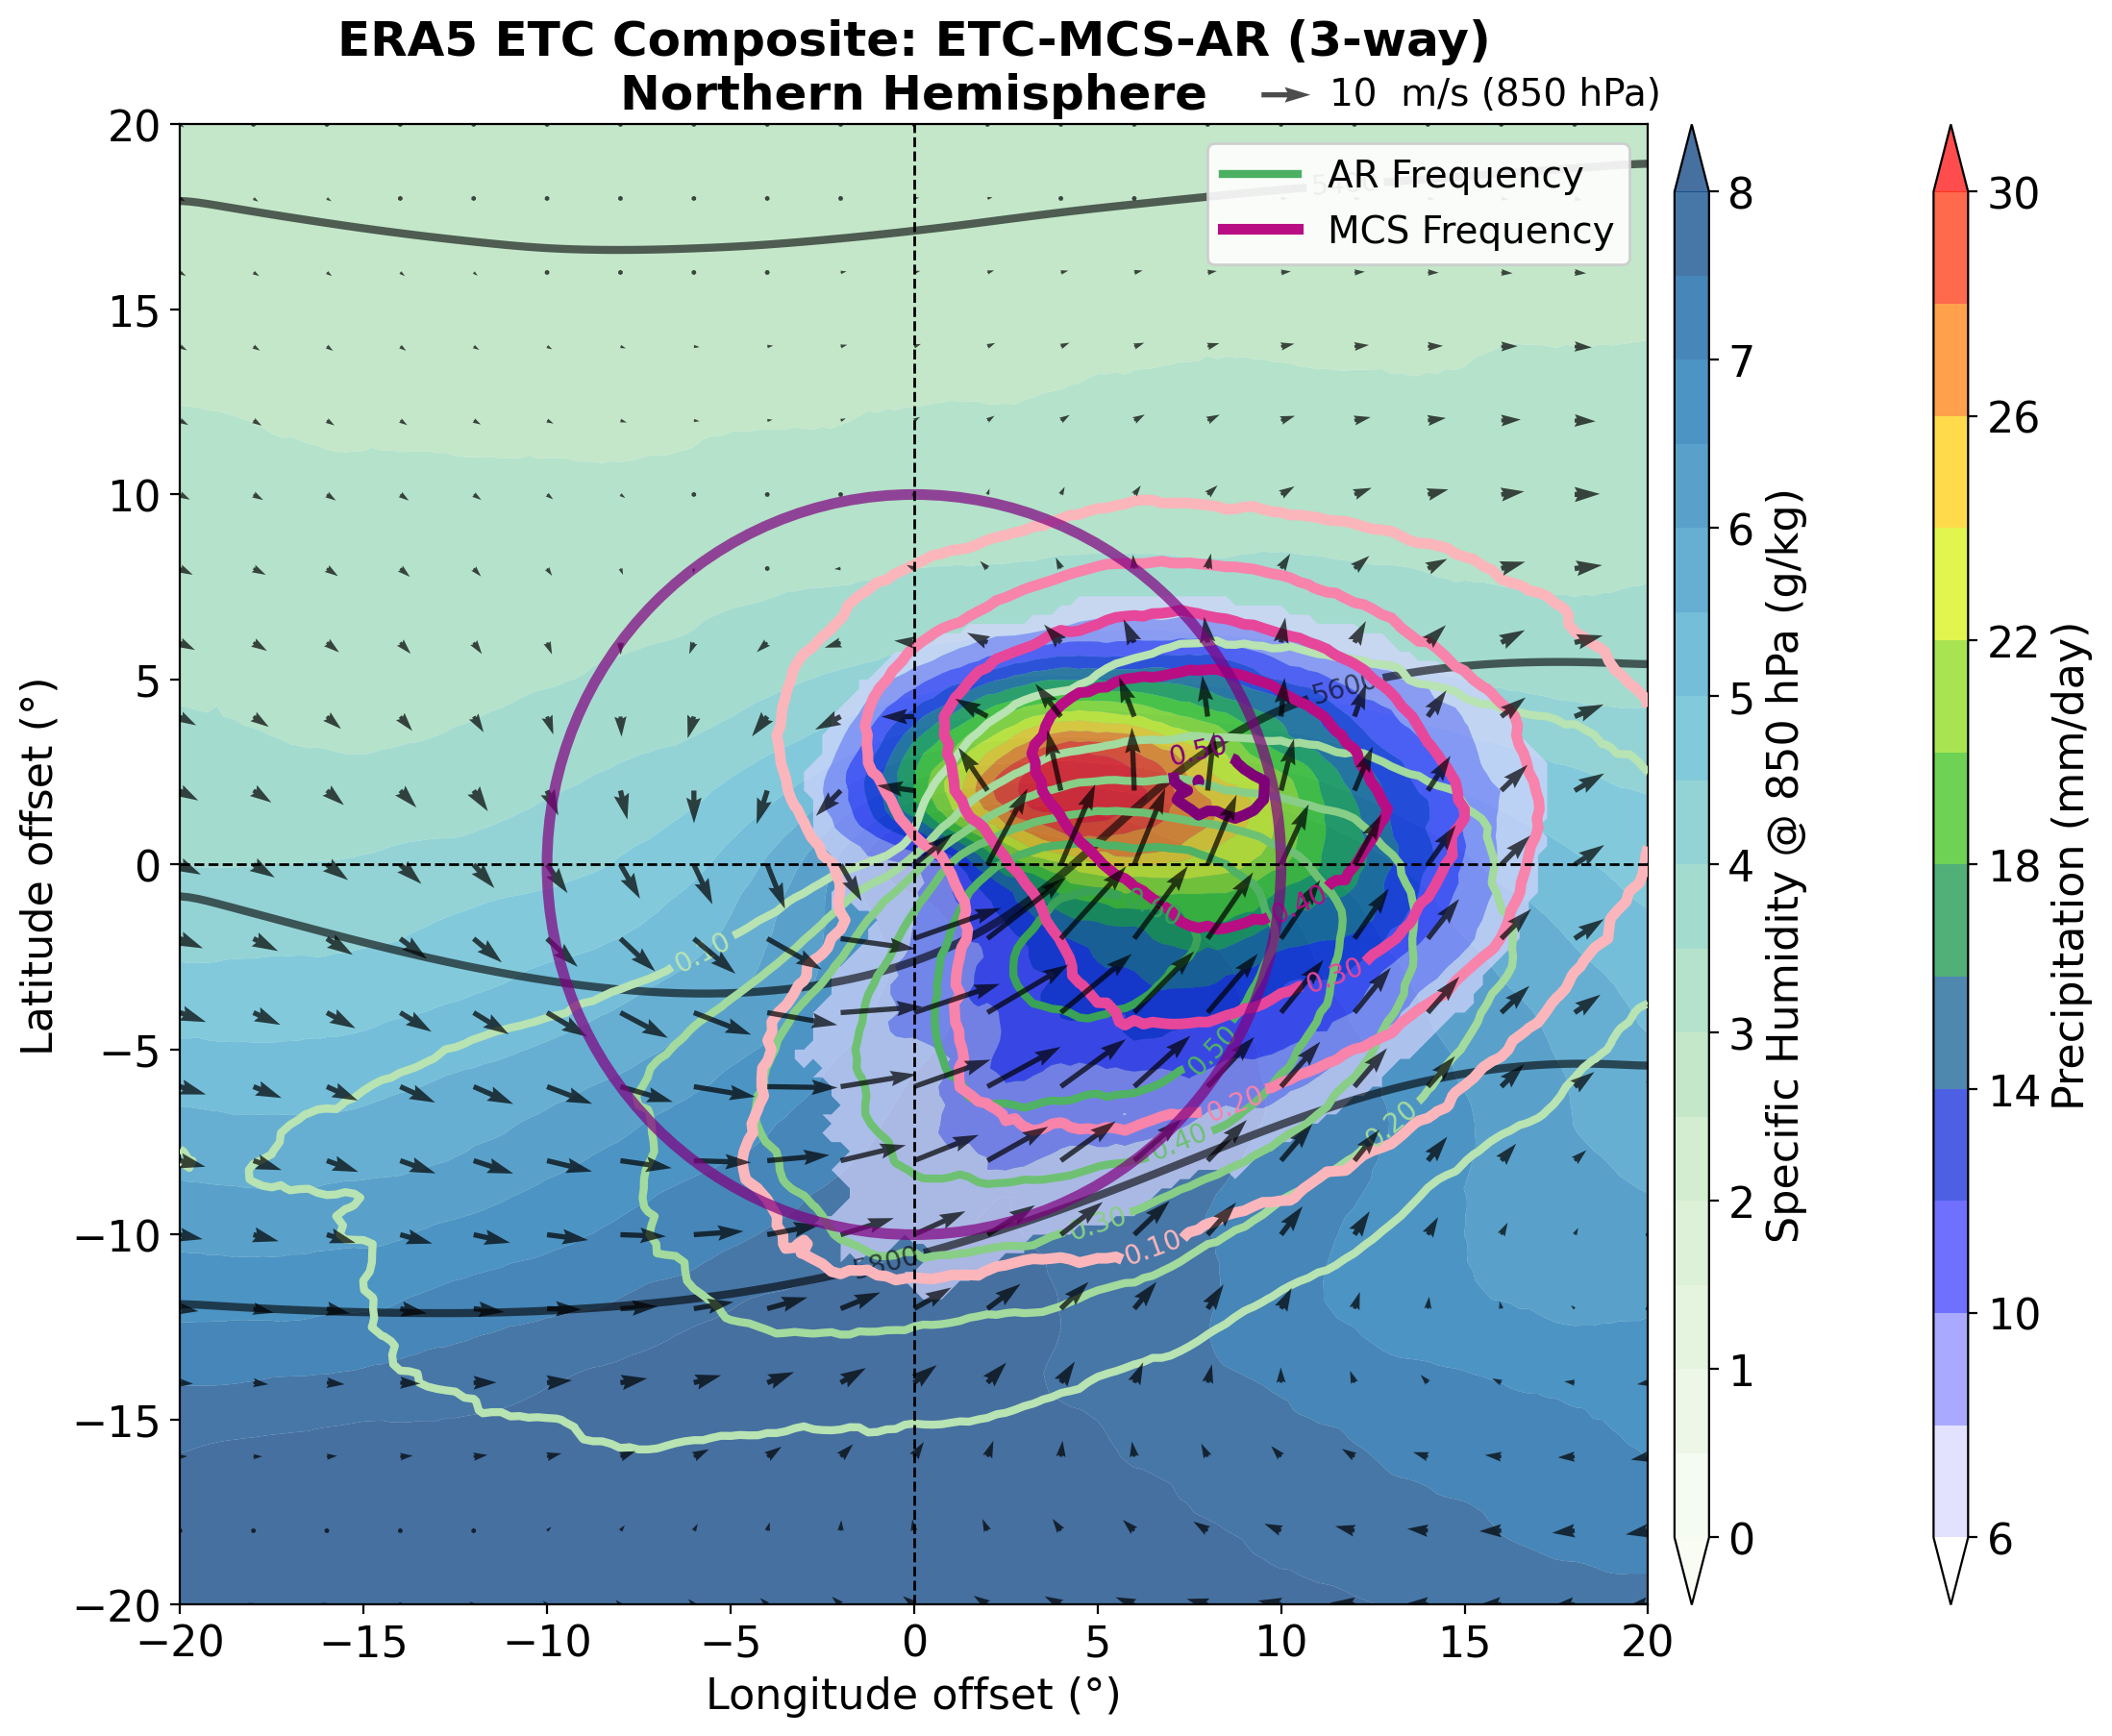

In [11]:
# Generate output filename
figname = f"{figdir}etc_composite_{hemisphere}_{overlap_type}_{source}.png"

# Create descriptive title
hemisphere_name = "Northern Hemisphere" if hemisphere == "nh" else "Southern Hemisphere"
overlap_names = {
    'isolated': 'Isolated ETC (no MCS/AR)',
    'mcs_only': 'ETC-MCS only',
    'ar_only': 'ETC-AR only',
    '3way': 'ETC-MCS-AR (3-way)',
    'all': 'All ETC'
}
overlap_desc = overlap_names.get(overlap_type, overlap_type)
title = f'{source_map[source]} ETC Composite: {overlap_desc}\n{hemisphere_name}'

# cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Oranges'), 0.3, 0.8)
# cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 1.0)
cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 0.8)
cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('RdPu'), 0.3, 1.0)

# Set contour levels based on overlap_type
if overlap_type == 'all':
    # Levels for 'all' category - weaker signals averaged across all cases
    shade_levels = np.arange(0, 6.1, 0.5)  # g/kg - specific humidity
    # shade_levels2 = np.arange(0.2, 0.71, 0.05)  # mm/hr - precipitation
    shade_levels2 = np.arange(5.0, 16.1, 1.0)  # mm/day - precipitation
    contour_levels = np.arange(5000, 6000, 100)  # meters - geopotential height
    contour_levels2 = np.arange(0.04, 0.21, 0.02)  # 0-1 frequency - AR
    contour_levels3 = np.arange(0.04, 0.21, 0.02)  # 0-1 frequency - MCS
else:
    # Levels for specific overlap categories - stronger signals
    shade_levels = np.arange(0, 8.1, 0.5)  # g/kg - specific humidity
    # shade_levels2 = np.arange(0.3, 1.51, 0.1)  # mm/hr - precipitation
    shade_levels2 = np.arange(6, 30.1, 2)  # mm/day - precipitation
    contour_levels = np.arange(4600, 6000, 200)  # meters - geopotential height
    contour_levels2 = np.arange(0.1, 0.81, 0.1)  # 0-1 frequency - AR
    contour_levels3 = np.arange(0.1, 0.61, 0.1)  # 0-1 frequency - MCS

# Create the plot
fig = plot_etc_composite(
    ds,
    main_width_ratios=[1, 0.2],
    main_wspace=0.03,
    cbar_width_ratios=[0.005, 0.005],
    cbar_wspace=6.5,
    shade_var='hus_850hPa',
    shade_levels=shade_levels,
    shade_cmap='GnBu',
    shade_alpha=0.75,
    shade_label='Specific Humidity @ 850 hPa (g/kg)',
    # Add precipitation overlay
    shade_var2='pr',
    shade_levels2=shade_levels2,
    shade_cmap2=cmaps.WhBlGrYeRe,
    shade_alpha2=0.7,
    shade_label2='Precipitation (mm/day)',
    # Add 500 hPa geopotential height contours
    contour_var='zg_500hPa',
    contour_levels=contour_levels,
    contour_smooth=2,
    contour_lw=3,
    # Add AR frequency contours
    contour_var2='ar_freq',
    contour_var2_legend='AR Frequency',
    contour_levels2=contour_levels2,
    contour_cmap2=cmap_ct2,
    contour_smooth2=0.5,
    contour_lw2=3.0,
    # Add MCS frequency contours
    contour_var3='mcs_freq',
    contour_var3_legend='MCS Frequency',
    contour_levels3=contour_levels3,
    contour_cmap3=cmap_ct3,
    contour_smooth3=0.5,
    contour_lw3=4.0,
    # Wind vectors at 850 hPa
    u_var='ua_850hPa',
    v_var='va_850hPa',
    vector_skip=8,
    quiver_scale=300,
    quiverkey_length=10, 
    quiverkey_unit=' m/s (850 hPa)',
    circle_radius=10.0,
    title=title,
    dpi=200,
    figname=figname,
)

print(f"\nComposite visualization created!")
print(f"Source: {source}")
print(f"Hemisphere: {hemisphere_name}")
print(f"Overlap type: {overlap_desc}")

Figure saved: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/etc_composite_nh_3way_era5_mcs.png


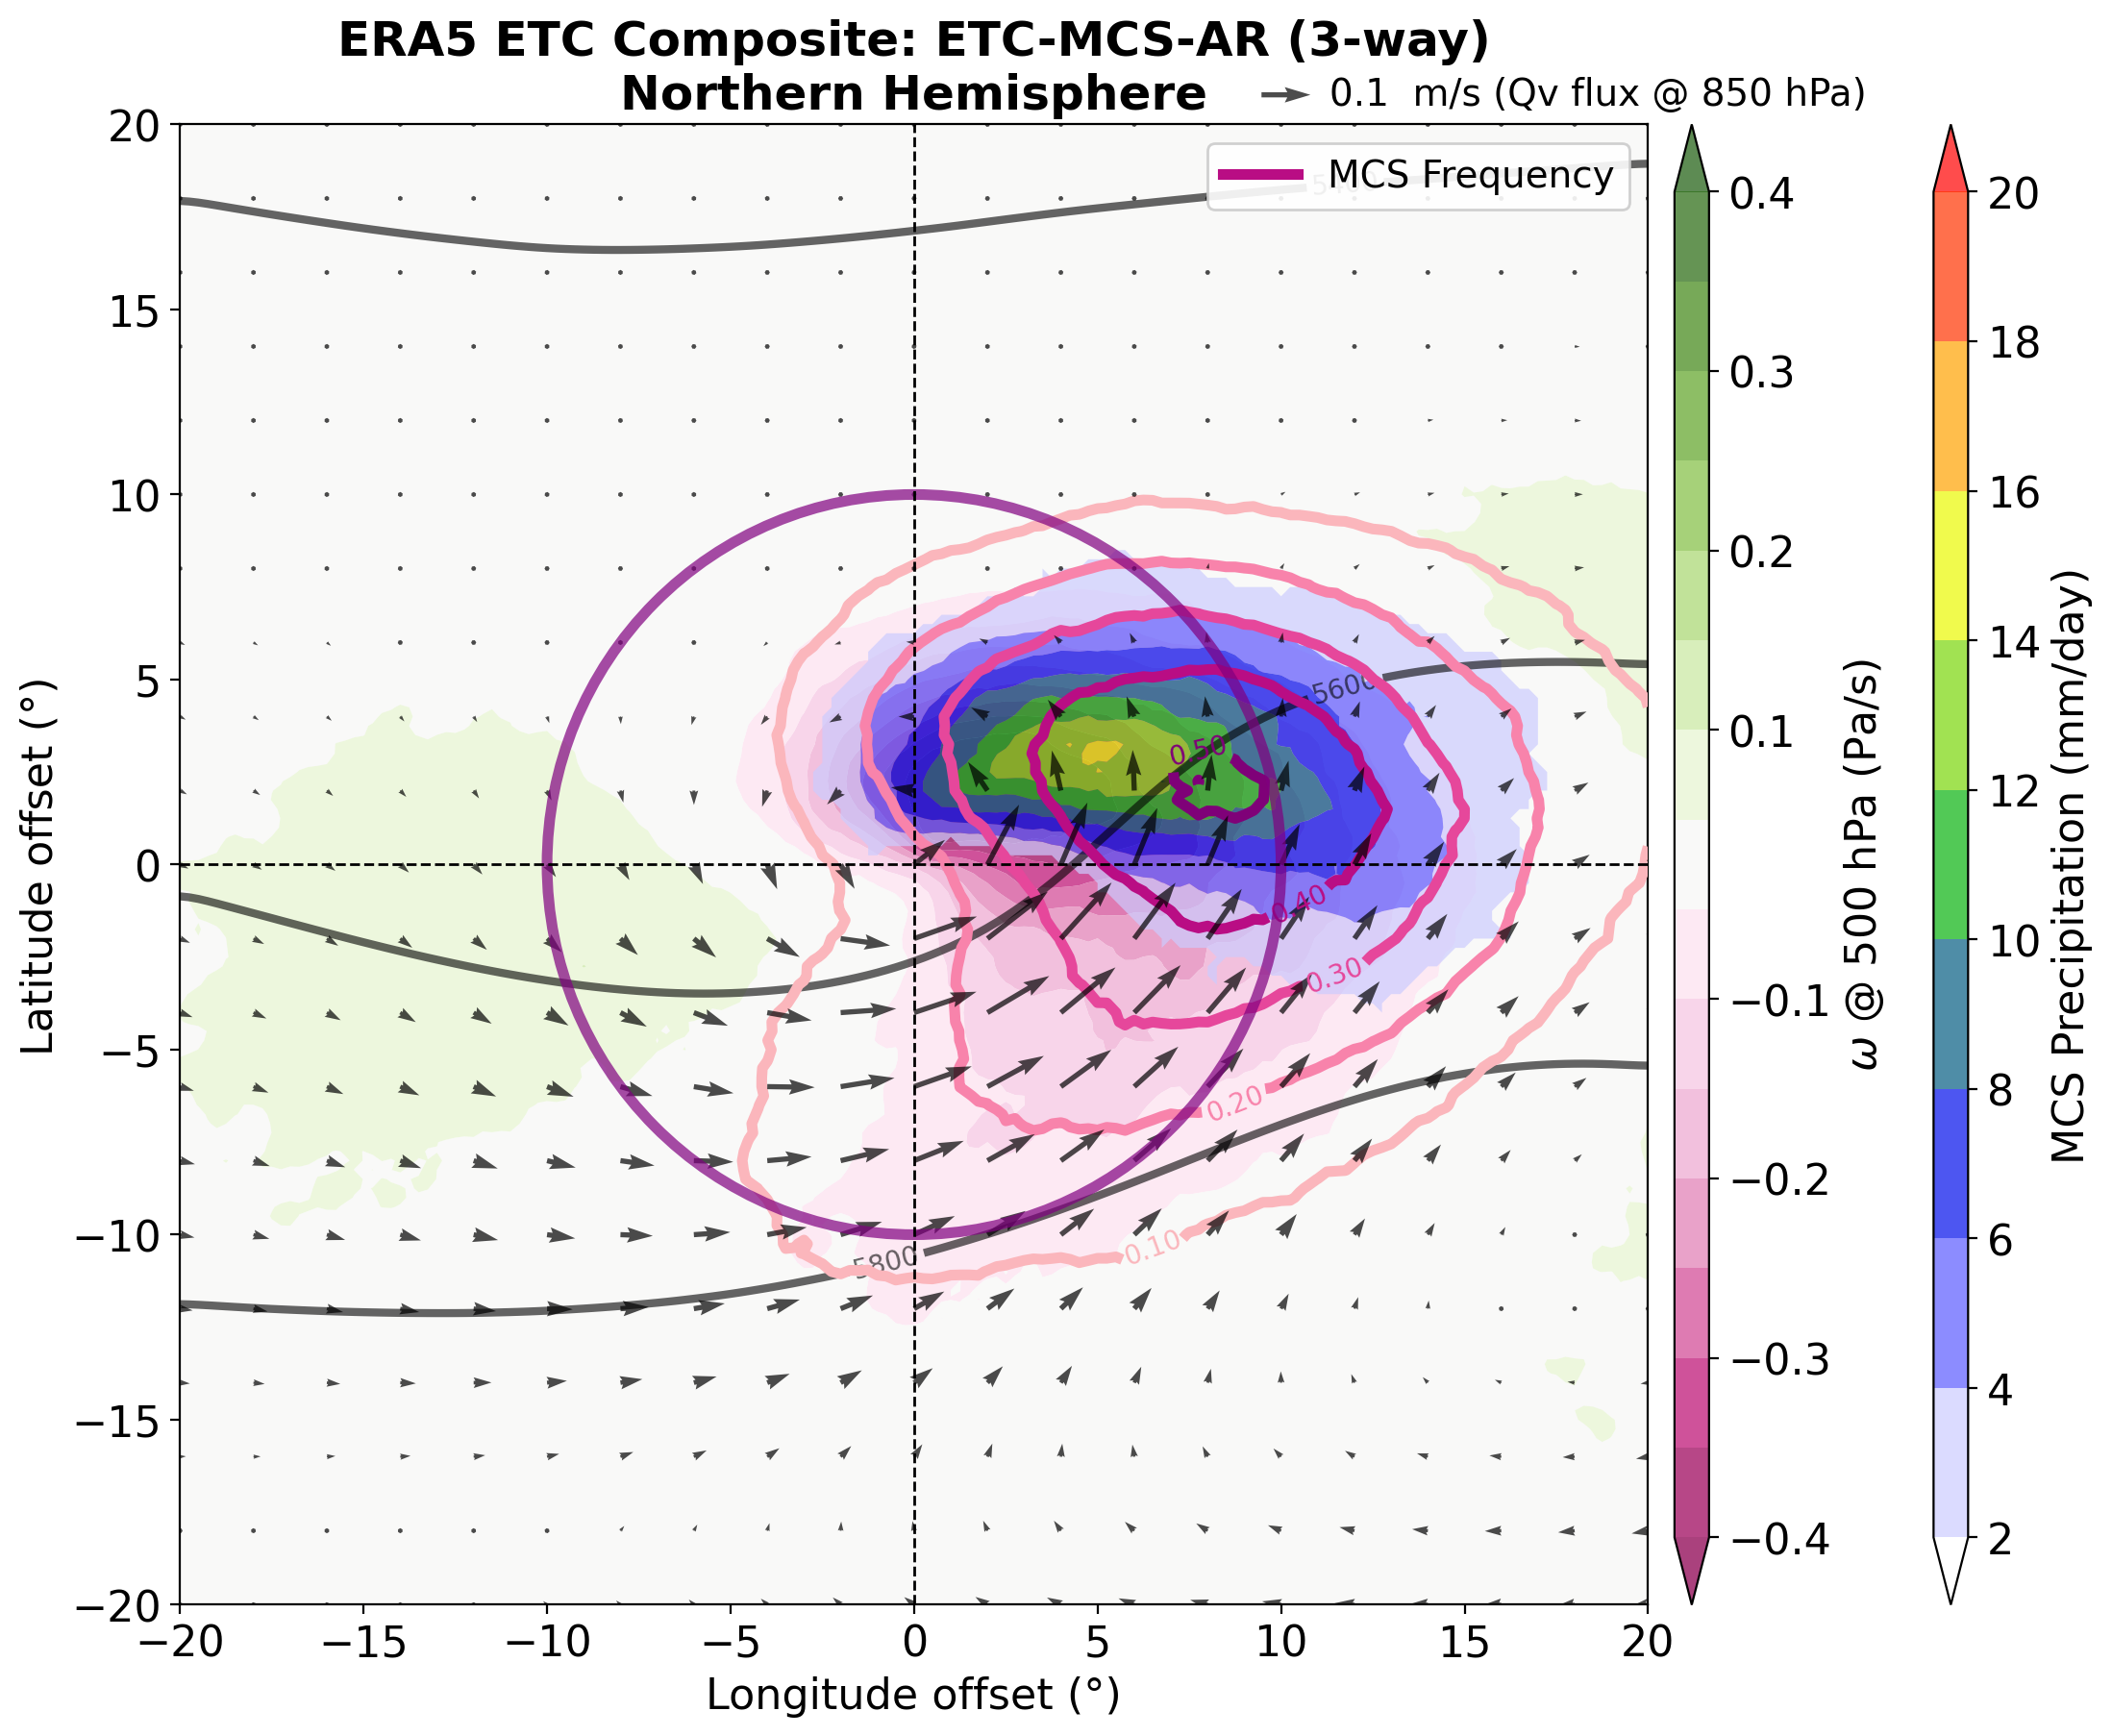

In [12]:
# Generate output filename
figname = f"{figdir}etc_composite_{hemisphere}_{overlap_type}_{source}_mcs.png"

# Create descriptive title
hemisphere_name = "Northern Hemisphere" if hemisphere == "nh" else "Southern Hemisphere"
overlap_names = {
    'isolated': 'Isolated ETC (no MCS/AR)',
    'mcs_only': 'ETC-MCS only',
    'ar_only': 'ETC-AR only',
    '3way': 'ETC-MCS-AR (3-way)',
    'all': 'All ETC'
}
overlap_desc = overlap_names.get(overlap_type, overlap_type)
title = f'{source_map[source]} ETC Composite: {overlap_desc}\n{hemisphere_name}'

# Omega at 500 hPa
shade_levels = np.array([x for x in np.arange(-0.4, 0.41, 0.05) if np.abs(x) > 1e-5])
cbar_ticks = np.array([x for x in np.arange(-0.4, 0.41, 0.1) if np.abs(x) > 1e-5])

# cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Oranges'), 0.3, 0.8)
# cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 1.0)
cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 0.8)
cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('RdPu'), 0.3, 1.0)

# Set contour levels based on overlap_type
if overlap_type == 'all':
    # Levels for 'all' category - weaker signals averaged across all cases
    # shade_levels2 = np.arange(0.05, 0.41, 0.05)  # mm/hr - precipitation
    shade_levels2 = np.arange(1, 10.1, 1)  # mm/day - precipitation
    contour_levels = np.arange(5000, 6000, 100)  # meters - geopotential height
    contour_levels2 = np.arange(0.04, 0.21, 0.02)  # 0-1 frequency - AR
    contour_levels3 = np.arange(0.04, 0.21, 0.02)  # 0-1 frequency - MCS
else:
    # Levels for specific overlap categories - stronger signals
    # shade_levels2 = np.arange(0.1, 0.81, 0.05)  # mm/hr - MCS precipitation
    shade_levels2 = np.arange(2, 20.1, 2)  # mm/day - MCS precipitation
    contour_levels = np.arange(4600, 6000, 200)  # meters - geopotential height
    contour_levels2 = np.arange(0.1, 0.81, 0.1)  # 0-1 frequency - AR
    contour_levels3 = np.arange(0.1, 0.61, 0.1)  # 0-1 frequency - MCS

# Create the plot
fig = plot_etc_composite(
    ds,
    main_width_ratios=[1, 0.2],
    main_wspace=0.03,
    cbar_width_ratios=[0.005, 0.005],
    cbar_wspace=6.5,
    shade_var='omega_500hPa',
    shade_levels=shade_levels,
    cbar_ticks=cbar_ticks,
    shade_cmap='PiYG',
    shade_alpha=0.75,
    shade_label='$\\omega$ @ 500 hPa (Pa/s)',
    # Add precipitation overlay
    shade_var2='pr_mcs',
    shade_levels2=shade_levels2,
    shade_cmap2=cmaps.WhBlGrYeRe,
    shade_alpha2=0.7,
    shade_label2='MCS Precipitation (mm/day)',
    # Add 500 hPa geopotential height contours
    contour_var='zg_500hPa',
    contour_levels=contour_levels,
    contour_smooth=2,
    contour_lw=3,
    # # Add AR frequency contours (varying shades of orange)
    # contour_var2='ar_freq',
    # contour_var2_legend='AR Frequency',
    # contour_levels2=contour_levels2,
    # contour_cmap2=cmap_ct2,
    # contour_smooth2=0.5,
    # contour_lw2=3.0,
    # Add MCS frequency contours (varying shades of green)
    contour_var3='mcs_freq',
    contour_var3_legend='MCS Frequency',
    contour_levels3=contour_levels3,
    contour_cmap3=cmap_ct3,
    contour_smooth3=0.5,
    contour_lw3=4.0,
    # Moisture flux vectors at 850 hPa
    u_var='qu_850hPa',
    v_var='qv_850hPa',
    vector_skip=8,
    quiver_scale=3,
    quiverkey_length=0.1, 
    quiverkey_unit=' m/s (Qv flux @ 850 hPa)',
    circle_radius=10.0,
    title=title,
    dpi=200,
    figname=figname,
)

Figure saved: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/etc_composite_nh_3way_era5_ar.png


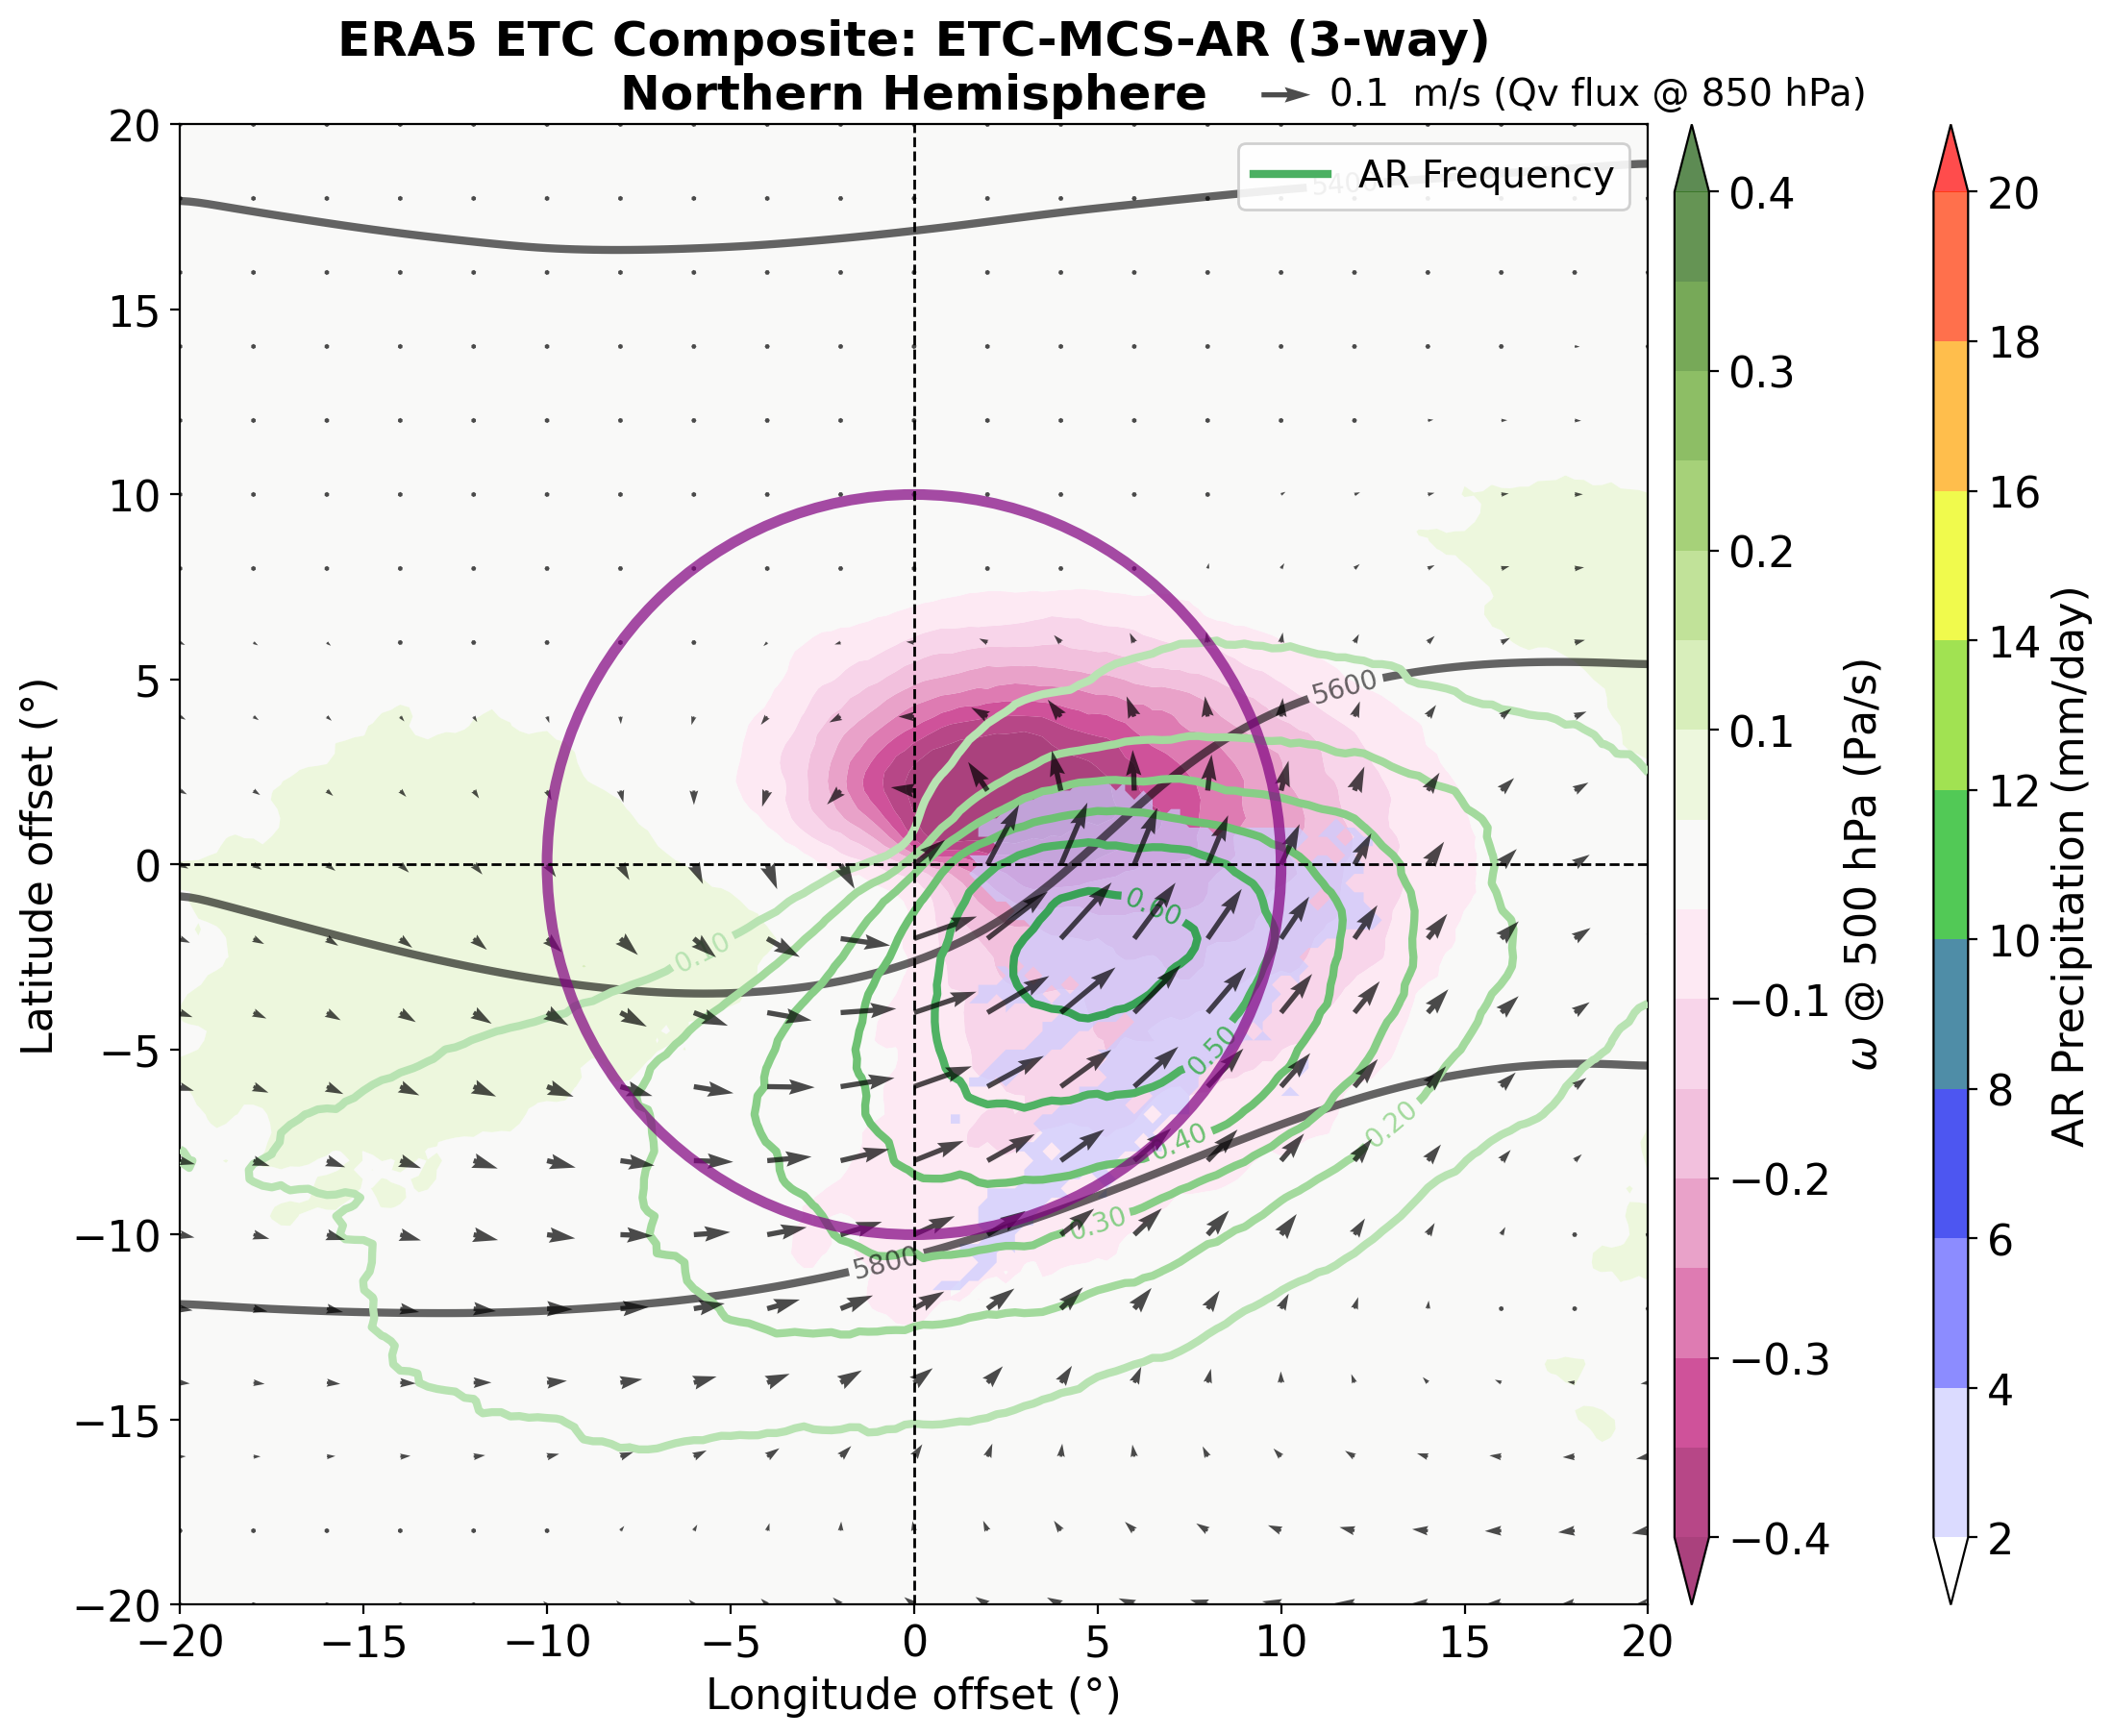

In [13]:
# Generate output filename
figname = f"{figdir}etc_composite_{hemisphere}_{overlap_type}_{source}_ar.png"

# Create descriptive title
hemisphere_name = "Northern Hemisphere" if hemisphere == "nh" else "Southern Hemisphere"
overlap_names = {
    'isolated': 'Isolated ETC (no MCS/AR)',
    'mcs_only': 'ETC-MCS only',
    'ar_only': 'ETC-AR only',
    '3way': 'ETC-MCS-AR (3-way)',
    'all': 'All ETC'
}
overlap_desc = overlap_names.get(overlap_type, overlap_type)
title = f'{source.upper()} ETC Composite: {overlap_desc}\n{hemisphere_name}'

# Omega at 500 hPa
shade_levels = np.array([x for x in np.arange(-0.4, 0.41, 0.05) if np.abs(x) > 1e-5])
cbar_ticks = np.array([x for x in np.arange(-0.4, 0.41, 0.1) if np.abs(x) > 1e-5])

# cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Oranges'), 0.3, 0.8)
# cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 1.0)
cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 0.8)
cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('RdPu'), 0.3, 1.0)

# Set contour levels based on overlap_type
if overlap_type == 'all':
    # Levels for 'all' category - weaker signals averaged across all cases
    # shade_levels2 = np.arange(0.05, 0.41, 0.05)  # mm/hr - precipitation
    shade_levels2 = np.arange(1, 10.1, 1)  # mm/day - AR precipitation
    contour_levels = np.arange(5000, 6000, 100)  # meters - geopotential height
    contour_levels2 = np.arange(0.04, 0.21, 0.02)  # 0-1 frequency - AR
    contour_levels3 = np.arange(0.04, 0.21, 0.02)  # 0-1 frequency - MCS
else:
    # Levels for specific overlap categories - stronger signals
    # shade_levels2 = np.arange(0.1, 0.81, 0.05)  # mm/hr - AR precipitation
    shade_levels2 = np.arange(2, 20.1, 2)  # mm/day - AR precipitation
    contour_levels = np.arange(4600, 6000, 200)  # meters - geopotential height
    contour_levels2 = np.arange(0.1, 0.81, 0.1)  # 0-1 frequency - AR
    contour_levels3 = np.arange(0.1, 0.61, 0.1)  # 0-1 frequency - MCS

# Create the plot
fig = plot_etc_composite(
    ds,
    main_width_ratios=[1, 0.2],
    main_wspace=0.03,
    cbar_width_ratios=[0.005, 0.005],
    cbar_wspace=6.5,
    shade_var='omega_500hPa',
    shade_levels=shade_levels,
    cbar_ticks=cbar_ticks,
    shade_cmap='PiYG',
    shade_alpha=0.75,
    shade_label='$\\omega$ @ 500 hPa (Pa/s)',
    # Add precipitation overlay
    shade_var2='pr_ar',
    shade_levels2=shade_levels2,
    shade_cmap2=cmaps.WhBlGrYeRe,
    shade_alpha2=0.7,
    shade_label2='AR Precipitation (mm/day)',
    # Add 500 hPa geopotential height contours
    contour_var='zg_500hPa',
    contour_levels=contour_levels,
    contour_smooth=2,
    contour_lw=3,
    # Add AR frequency contours (varying shades of orange)
    contour_var2='ar_freq',
    contour_var2_legend='AR Frequency',
    contour_levels2=contour_levels2,
    contour_cmap2=cmap_ct2,
    contour_smooth2=0.5,
    contour_lw2=3.0,
    # # Add MCS frequency contours (varying shades of green)
    # contour_var3='mcs_freq',
    # contour_var3_legend='MCS Frequency',
    # contour_levels3=contour_levels3,
    # contour_cmap3=cmap_ct3,
    # contour_smooth3=0.5,
    # contour_lw3=4.0,
    # Moisture flux vectors at 850 hPa
    u_var='qu_850hPa',
    v_var='qv_850hPa',
    vector_skip=8,
    quiver_scale=3,
    quiverkey_length=0.1, 
    quiverkey_unit=' m/s (Qv flux @ 850 hPa)',
    circle_radius=10.0,
    title=title,
    dpi=200,
    figname=figname,
)

Figure saved: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/etc_composite_nh_3way_era5_mcs_rainfrac.png


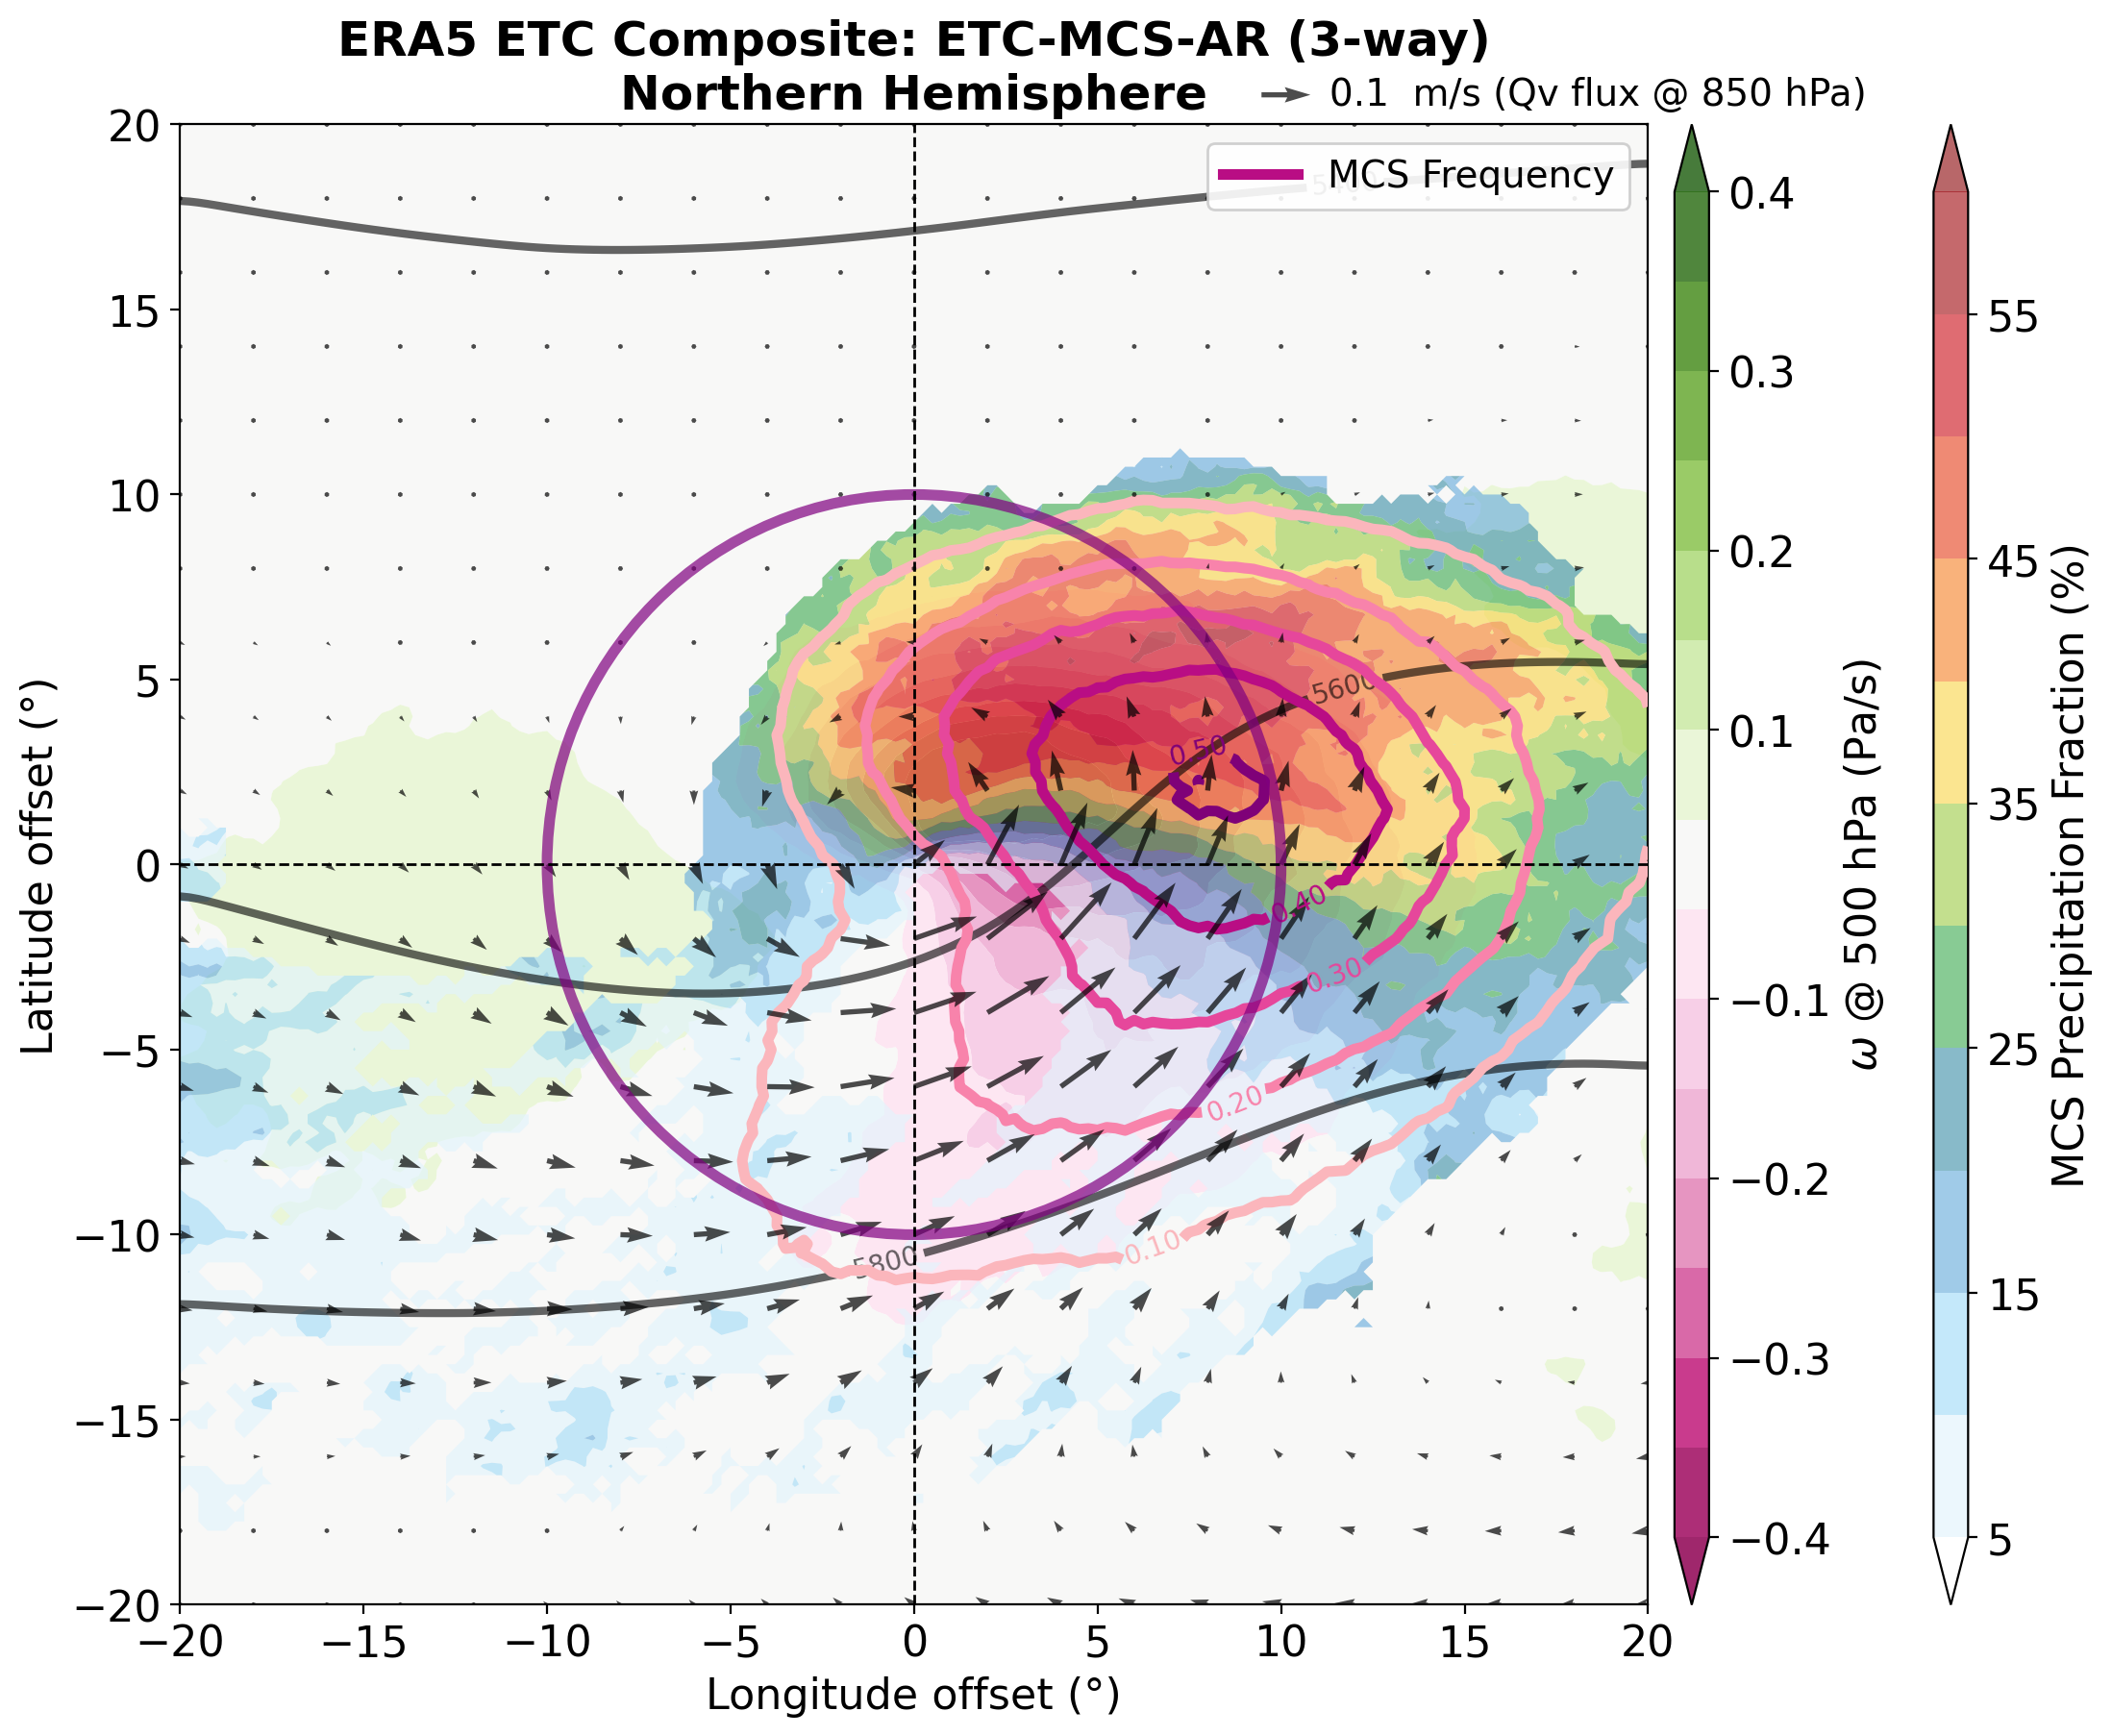

In [14]:
# Generate output filename
figname = f"{figdir}etc_composite_{hemisphere}_{overlap_type}_{source}_mcs_rainfrac.png"

# Create descriptive title
hemisphere_name = "Northern Hemisphere" if hemisphere == "nh" else "Southern Hemisphere"
overlap_names = {
    'isolated': 'Isolated ETC (no MCS/AR)',
    'mcs_only': 'ETC-MCS only',
    'ar_only': 'ETC-AR only',
    '3way': 'ETC-MCS-AR (3-way)',
    'all': 'All ETC'
}
overlap_desc = overlap_names.get(overlap_type, overlap_type)
title = f'{source_map[source]} ETC Composite: {overlap_desc}\n{hemisphere_name}'

# Omega at 500 hPa
shade_levels = np.array([x for x in np.arange(-0.4, 0.41, 0.05) if np.abs(x) > 1e-5])
cbar_ticks = np.array([x for x in np.arange(-0.4, 0.41, 0.1) if np.abs(x) > 1e-5])

# cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Oranges'), 0.3, 0.8)
# cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 1.0)
cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 0.8)
cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('RdPu'), 0.3, 1.0)

# Set contour levels based on overlap_type
if overlap_type == 'all':
    # Levels for 'all' category - weaker signals averaged across all cases
    shade_levels2 = np.arange(5, 61, 5)  # % - MCS precipitation fraction
    contour_levels = np.arange(5000, 6000, 100)  # meters - geopotential height
    contour_levels2 = np.arange(0.04, 0.21, 0.02)  # 0-1 frequency - AR
    contour_levels3 = np.arange(0.04, 0.21, 0.02)  # 0-1 frequency - MCS
else:
    # Levels for specific overlap categories - stronger signals
    shade_levels2 = np.arange(5, 61, 5)  # % - MCS precipitation fraction
    contour_levels = np.arange(4600, 6000, 200)  # meters - geopotential height
    contour_levels2 = np.arange(0.1, 0.81, 0.1)  # 0-1 frequency - AR
    contour_levels3 = np.arange(0.1, 0.61, 0.1)  # 0-1 frequency - MCS

# Create the plot
fig = plot_etc_composite(
    ds,
    main_width_ratios=[1, 0.2],
    main_wspace=0.03,
    cbar_width_ratios=[0.005, 0.005],
    cbar_wspace=6.5,
    shade_var='omega_500hPa',
    shade_levels=shade_levels,
    cbar_ticks=cbar_ticks,
    shade_cmap='PiYG',
    shade_alpha=0.85,
    shade_label='$\\omega$ @ 500 hPa (Pa/s)',
    # Add precipitation overlay
    shade_var2='prfrac_mcs',
    shade_levels2=shade_levels2,
    shade_cmap2=cmaps.WhiteBlueGreenYellowRed,
    shade_alpha2=0.65,
    shade_label2='MCS Precipitation Fraction (%)',
    # Add 500 hPa geopotential height contours
    contour_var='zg_500hPa',
    contour_levels=contour_levels,
    contour_smooth=2,
    contour_lw=3,
    # # Add AR frequency contours (varying shades of orange)
    # contour_var2='ar_freq',
    # contour_var2_legend='AR Frequency',
    # contour_levels2=contour_levels2,
    # contour_cmap2=cmap_ct2,
    # contour_smooth2=0.5,
    # contour_lw2=3.0,
    # Add MCS frequency contours (varying shades of green)
    contour_var3='mcs_freq',
    contour_var3_legend='MCS Frequency',
    contour_levels3=contour_levels3,
    contour_cmap3=cmap_ct3,
    contour_smooth3=0.5,
    contour_lw3=4.0,
    # Moisture flux vectors at 850 hPa
    u_var='qu_850hPa',
    v_var='qv_850hPa',
    vector_skip=8,
    quiver_scale=3,
    quiverkey_length=0.1, 
    quiverkey_unit=' m/s (Qv flux @ 850 hPa)',
    circle_radius=10.0,
    title=title,
    dpi=200,
    figname=figname,
)

Figure saved: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/etc_composite_nh_3way_era5_ar_rainfrac.png


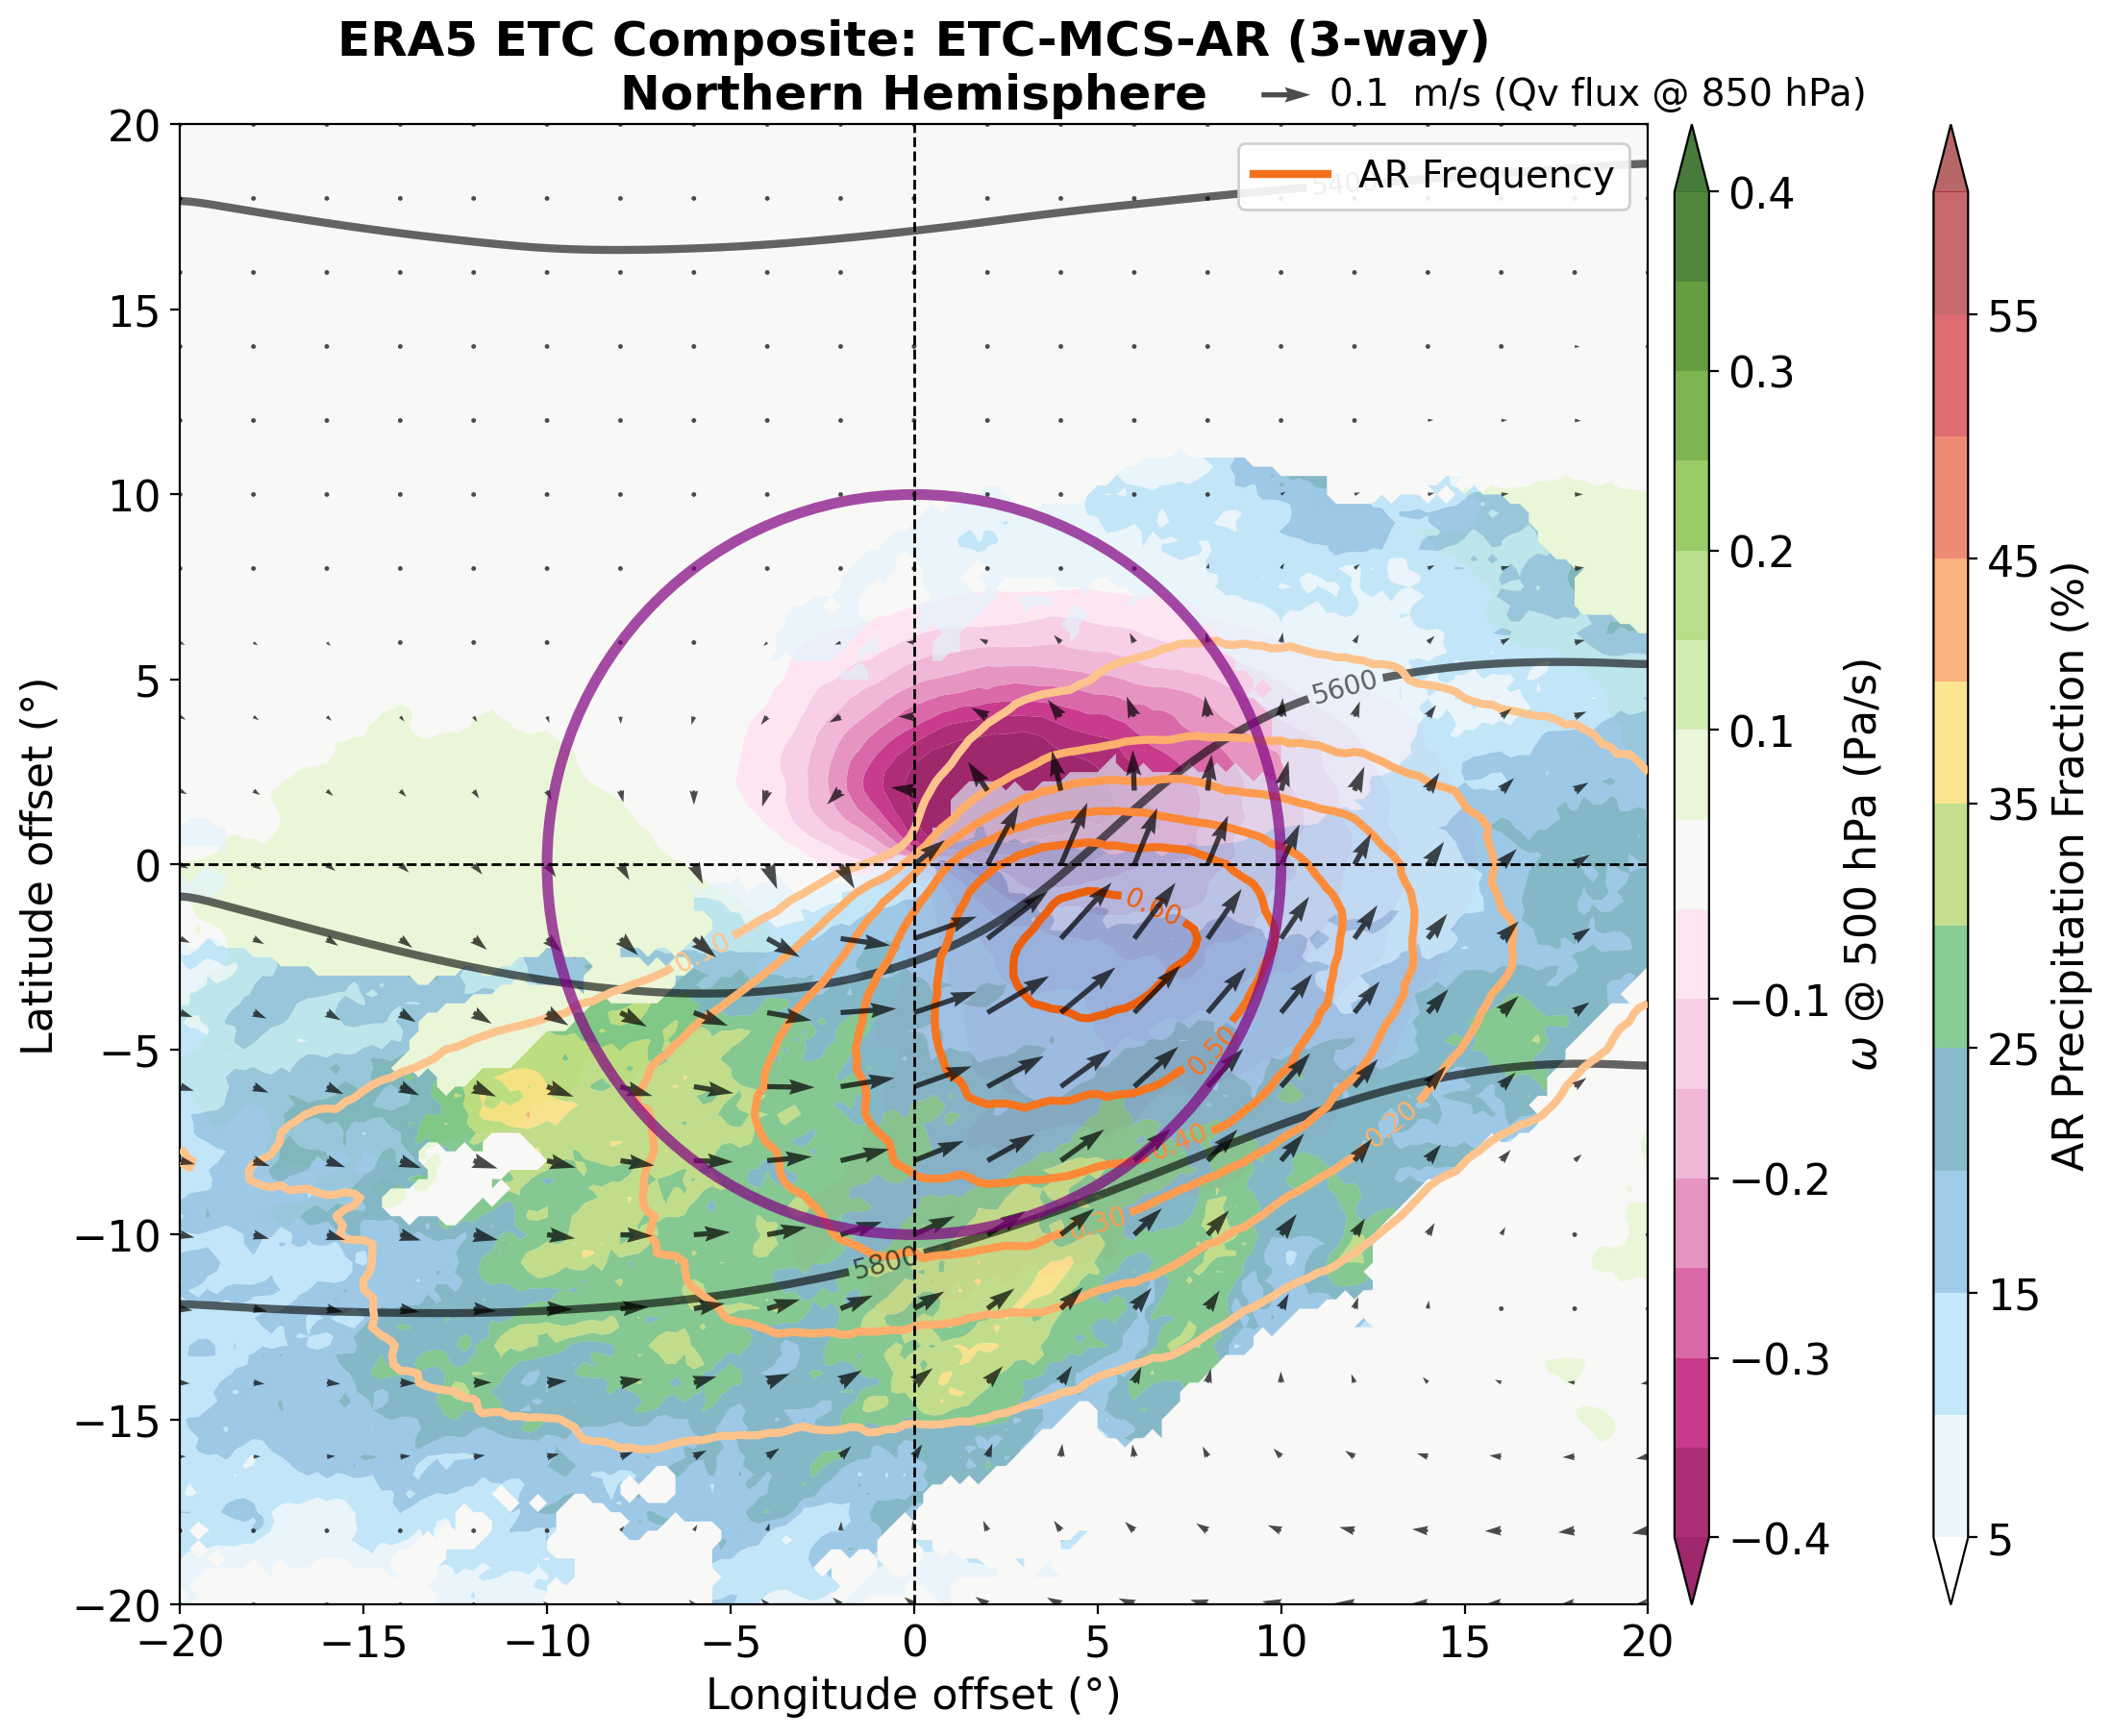

In [15]:
# Generate output filename
figname = f"{figdir}etc_composite_{hemisphere}_{overlap_type}_{source}_ar_rainfrac.png"

# Create descriptive title
hemisphere_name = "Northern Hemisphere" if hemisphere == "nh" else "Southern Hemisphere"
overlap_names = {
    'isolated': 'Isolated ETC (no MCS/AR)',
    'mcs_only': 'ETC-MCS only',
    'ar_only': 'ETC-AR only',
    '3way': 'ETC-MCS-AR (3-way)',
    'all': 'All ETC'
}
overlap_desc = overlap_names.get(overlap_type, overlap_type)
title = f'{source_map[source]} ETC Composite: {overlap_desc}\n{hemisphere_name}'

# Omega at 500 hPa
shade_levels = np.array([x for x in np.arange(-0.4, 0.41, 0.05) if np.abs(x) > 1e-5])
cbar_ticks = np.array([x for x in np.arange(-0.4, 0.41, 0.1) if np.abs(x) > 1e-5])

cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Oranges'), 0.3, 0.8)
cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 1.0)

# Set contour levels based on overlap_type
if overlap_type == 'all':
    # Levels for 'all' category - weaker signals averaged across all cases
    shade_levels2 = np.arange(5, 61, 5)  # % - MCS precipitation fraction
    contour_levels = np.arange(5000, 6000, 100)  # meters - geopotential height
    contour_levels2 = np.arange(0.04, 0.21, 0.02)  # 0-1 frequency - AR
    contour_levels3 = np.arange(0.04, 0.21, 0.02)  # 0-1 frequency - MCS
else:
    # Levels for specific overlap categories - stronger signals
    shade_levels2 = np.arange(5, 61, 5)  # % - MCS precipitation fraction
    contour_levels = np.arange(4600, 6000, 200)  # meters - geopotential height
    contour_levels2 = np.arange(0.1, 0.81, 0.1)  # 0-1 frequency - AR
    contour_levels3 = np.arange(0.1, 0.61, 0.1)  # 0-1 frequency - MCS

# Create the plot
fig = plot_etc_composite(
    ds,
    main_width_ratios=[1, 0.2],
    main_wspace=0.03,
    cbar_width_ratios=[0.005, 0.005],
    cbar_wspace=6.5,
    shade_var='omega_500hPa',
    shade_levels=shade_levels,
    cbar_ticks=cbar_ticks,
    shade_cmap='PiYG',
    shade_alpha=0.85,
    shade_label='$\\omega$ @ 500 hPa (Pa/s)',
    # Add precipitation overlay
    shade_var2='prfrac_ar',
    shade_levels2=shade_levels2,
    shade_cmap2=cmaps.WhiteBlueGreenYellowRed,
    shade_alpha2=0.65,
    shade_label2='AR Precipitation Fraction (%)',
    # Add 500 hPa geopotential height contours
    contour_var='zg_500hPa',
    contour_levels=contour_levels,
    contour_smooth=2,
    contour_lw=3,
    # Add AR frequency contours (varying shades of orange)
    contour_var2='ar_freq',
    contour_var2_legend='AR Frequency',
    contour_levels2=contour_levels2,
    contour_cmap2=cmap_ct2,
    contour_smooth2=0.5,
    contour_lw2=3.0,
    # Moisture flux vectors at 850 hPa
    u_var='qu_850hPa',
    v_var='qv_850hPa',
    vector_skip=8,
    quiver_scale=3,
    quiverkey_length=0.1, 
    quiverkey_unit=' m/s (Qv flux @ 850 hPa)',
    circle_radius=10.0,
    title=title,
    dpi=200,
    figname=figname,
)

## 6. Create Multiple Composites

Generate plots for all overlap categories to compare environmental conditions.

In [16]:
# Loop through all overlap categories
overlap_categories = ['isolated', 'mcs_only', 'ar_only', 'all']
overlap_names = {
    'isolated': 'Isolated ETC (no MCS/AR)',
    'mcs_only': 'ETC-MCS only',
    'ar_only': 'ETC-AR only',
    # '3way': 'ETC-MCS-AR (3-way)',
    'all': 'All ETC'
}

hemisphere_name = "Northern Hemisphere" if hemisphere == "nh" else "Southern Hemisphere"

print(f"Creating composites for all overlap categories...")
print(f"Source: {source}")
print(f"Hemisphere: {hemisphere_name}\n")

for overlap_cat in overlap_categories:
    # Load composite file
    composite_file = f"{data_dir}etc_2d_composite_{hemisphere}_{overlap_cat}.nc"
    
    if not os.path.exists(composite_file):
        print(f"  Skipping {overlap_cat}: file not found")
        continue
    
    print(f"  Processing {overlap_cat}...")
    ds_comp = xr.open_dataset(composite_file)
    
    # Compute moisture flux for this composite
    hus_kgkg_comp = ds_comp.hus_850hPa / 1000.0
    ds_comp['qu_850hPa'] = ds_comp.ua_850hPa * hus_kgkg_comp
    ds_comp['qv_850hPa'] = ds_comp.va_850hPa * hus_kgkg_comp
    # Convert precipitation from mm/h to mm/day
    ds_comp['pr'] = ds_comp['pr'] * 24.0
    
    # Generate output filename
    figname = f"{figdir}etc_composite_{hemisphere}_{overlap_cat}_{source}.png"
    
    # Create title
    overlap_desc = overlap_names[overlap_cat]
    title = f'{source_map[source]} ETC Composite: {overlap_desc}\n{hemisphere_name}'

    # cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Oranges'), 0.3, 0.8)
    # cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 1.0)
    cmap_ct2 = truncate_colormap(mpl.colormaps.get_cmap('Greens'), 0.3, 0.8)
    cmap_ct3 = truncate_colormap(mpl.colormaps.get_cmap('RdPu'), 0.3, 1.0)
    
    # Set contour levels based on overlap_cat
    if overlap_cat == 'all':
        # Levels for 'all' category - weaker signals averaged across all cases
        shade_levels = np.arange(0, 6.1, 0.5)  # g/kg - specific humidity
        # shade_levels2 = np.arange(0.2, 0.71, 0.05)  # mm/hr - precipitation
        shade_levels2 = np.arange(3, 16.1, 1)  # mm/day - precipitation
        contour_levels = np.arange(5000, 6000, 100)  # meters - geopotential height
        contour_levels2 = np.arange(0.04, 0.21, 0.02)  # 0-1 frequency - AR
        contour_levels3 = np.arange(0.04, 0.21, 0.02)  # 0-1 frequency - MCS
    else:
        # Levels for specific overlap categories - stronger signals
        shade_levels = np.arange(0, 8.1, 0.5)  # g/kg - specific humidity
        # shade_levels2 = np.arange(0.3, 1.51, 0.1)  # mm/hr - precipitation
        shade_levels2 = np.arange(3, 16.1, 1)  # mm/day - precipitation
        contour_levels = np.arange(4600, 6000, 200)  # meters - geopotential height
        contour_levels2 = np.arange(0.1, 0.81, 0.1)  # 0-1 frequency - AR
        contour_levels3 = np.arange(0.1, 0.61, 0.1)  # 0-1 frequency - MCS
    
    # Configure frequency contours based on overlap category
    if overlap_cat == 'isolated':
        # Isolated: no frequency contours
        contour_var2 = None
        contour_var3 = None
    elif overlap_cat == 'mcs_only':
        # MCS only: show MCS frequency
        contour_var2 = None
        contour_var3 = 'mcs_freq'
    elif overlap_cat == 'ar_only':
        # AR only: show AR frequency
        contour_var2 = 'ar_freq'
        contour_var3 = None
    else:
        # Default for '3way' and 'all'
        contour_var2 = 'ar_freq'
        contour_var3 = 'mcs_freq'
    
    # Create the plot
    fig = plot_etc_composite(
        ds_comp,
        main_width_ratios=[1, 0.2],
        main_wspace=0.03,
        cbar_width_ratios=[0.005, 0.005],
        cbar_wspace=6.5,
        shade_var='hus_850hPa',
        shade_levels=shade_levels,
        shade_cmap='GnBu',
        shade_alpha=0.8,
        shade_label='Specific Humidity @ 850 hPa (g/kg)',
        # Add precipitation overlay
        shade_var2='pr',
        shade_levels2=shade_levels2,
        shade_cmap2=cmaps.WhBlGrYeRe,
        shade_alpha2=0.6,
        shade_label2='Precipitation (mm/day)',
        # Add 500 hPa geopotential height contours
        contour_var='zg_500hPa',
        contour_levels=contour_levels,
        contour_smooth=2,
        contour_lw=3,
        # Add AR frequency contours (varying shades of orange) - conditional
        contour_var2=contour_var2,
        contour_var2_legend='AR Frequency',
        contour_levels2=contour_levels2,
        contour_cmap2=cmap_ct2,
        contour_smooth2=0.5,
        contour_lw2=3.0,
        # Add MCS frequency contours (varying shades of green) - conditional
        contour_var3=contour_var3,
        contour_var3_legend='MCS Frequency',
        contour_levels3=contour_levels3,
        contour_cmap3=cmap_ct3,
        contour_smooth3=0.5,
        contour_lw3=4.0,
        # Wind vectors at 850 hPa
        u_var='ua_850hPa',
        v_var='va_850hPa',
        vector_skip=8,
        quiverkey_length=10, 
        quiverkey_unit=' m/s (850 hPa)',
        circle_radius=10.0,
        title=title,
        dpi=200,
        figname=figname,
    )
    
    plt.close(fig)
    
    print(f"    Saved: {figname}")

print(f"\nAll composite visualizations created in: {figdir}")

Creating composites for all overlap categories...
Source: era5
Hemisphere: Northern Hemisphere

  Processing isolated...


Figure saved: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/etc_composite_nh_isolated_era5.png
    Saved: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/etc_composite_nh_isolated_era5.png
  Processing mcs_only...


Figure saved: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/etc_composite_nh_mcs_only_era5.png
    Saved: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/etc_composite_nh_mcs_only_era5.png
  Processing ar_only...


Figure saved: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/etc_composite_nh_ar_only_era5.png
    Saved: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/etc_composite_nh_ar_only_era5.png
  Processing all...


Figure saved: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/etc_composite_nh_all_era5.png
    Saved: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/etc_composite_nh_all_era5.png

All composite visualizations created in: /pscratch/sd/w/wcmca1/hackathon/tmp/allfixes_20260921/final_run/figures/etc_composites/era5/


## 7. Summary

This notebook provides tools to visualize ETC composite data:

1. **Flexible configuration**: Set source, hemisphere, and overlap category
2. **Automatic scaling**: Precipitation units adjusted per source
3. **Composite plotting function**: Adapted from `visualize_etc_2d_data.ipynb`
4. **Batch processing**: Create plots for all overlap categories

**Key Variables:**
- **Primary shading**: Specific humidity at 850 hPa (g/kg)
- **Overlay shading**: Precipitation rate (mm/h)
- **Contours**: Geopotential height at 500 hPa (m)
- **Vectors**: Wind at 850 hPa (m/s)

**Customization:**
- Adjust `shade_levels` and `shade_levels2` to change color ranges
- Modify `contour_levels` for different height intervals
- Change `vector_skip` to control vector density
- Use `xlim` and `ylim` to zoom into specific regions
- Adjust `circle_radius` to highlight a specific distance from center

**Precipitation Scaling:**
- ERA5: 1.0 (already in mm/h)
- SCREAM: 3,600,000 (kg/m²/s → mm/h)
- Other sources: 3,600 (kg/m²/s → mm/h)

**Next Steps:**
- Compare different overlap categories side-by-side
- Examine differences between NH and SH composites
- Analyze differences across model sources
- Add additional variables (e.g., AR/MCS frequency masks)